In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D

x_c = [2. 1.]
w = [1. 1.]

Dot product:
2.0*1.0 + 1.0*1.0 = 3.0

w^T w:
1.0^2 + 1.0^2 = 2.0

Projection:
(3.0/2.0) * w = [1.5 1.5]
Note: for a unit vector w for which w^T w = 1, the projection would be just the dot product times w (proj = (x_c @ w) * w).


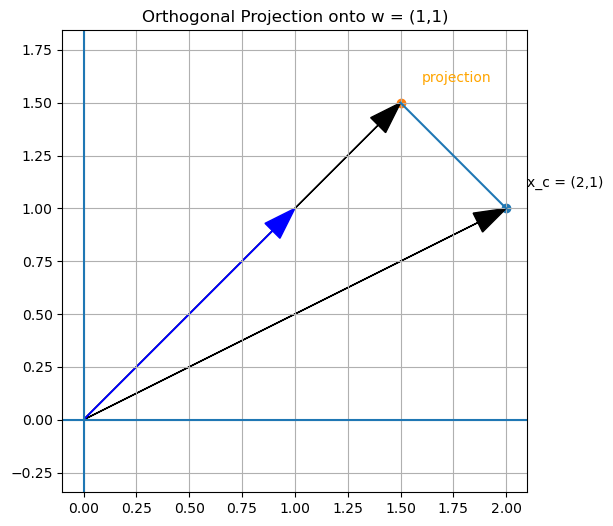

In [3]:
## simple projection of 2d data on a vector

import numpy as np
import matplotlib.pyplot as plt

# ---- Simple vectors (easy mental math) ----
x_c = np.array([2.0, 1.0])
w = np.array([1.0, 1.0])   # NOT unit length

# ---- Compute projection ----
dot = x_c @ w              # x1*w1 + x2*w2
w_norm_sq = w @ w          # w1^2 + w2^2

proj = (dot / w_norm_sq) * w

# ---- Print math explicitly ----
print("x_c =", x_c)
print("w =", w)
print()
print("Dot product:")
print(f"{x_c[0]}*{w[0]} + {x_c[1]}*{w[1]} = {dot}")
print()
print("w^T w:")
print(f"{w[0]}^2 + {w[1]}^2 = {w_norm_sq}")
print()
print("Projection:")
print(f"({dot}/{w_norm_sq}) * w = {proj}")
print('Note: for a unit vector w for which w^T w = 1, the projection would be just the dot product times w (proj = (x_c @ w) * w).')

# ---- Plot ----
plt.figure(figsize=(6,6))

# grid
plt.axhline(0)
plt.axvline(0)
plt.grid(True)

# axis limits
plt.xlim(-1, 3)
plt.ylim(-1, 3)

# draw direction line (span of w)
#t = np.linspace(-1, 3, 100)
#line = np.outer(t, w)
#plt.plot(line[:,0], line[:,1], color='cyan', linestyle='--')


# original point
plt.scatter(*x_c)
plt.text(x_c[0]+0.1, x_c[1]+0.1, "x_c = (2,1)")

# projected point
plt.scatter(*proj)
plt.text(proj[0]+0.1, proj[1]+0.1, "projection", color='orange')



# arrow: origin → x_c
plt.arrow(0, 0, x_c[0], x_c[1], length_includes_head=True, head_width=0.1, color='black')

# arrow: origin → projection
plt.arrow(0, 0, proj[0], proj[1], length_includes_head=True, head_width=0.1, color='black')

# arrow: origin → w
plt.arrow(0, 0, w[0], w[1], length_includes_head=True, head_width=0.1, color='blue')

# perpendicular drop
plt.plot([x_c[0], proj[0]], [x_c[1], proj[1]])


plt.title("Orthogonal Projection onto w = (1,1)")
plt.axis('equal')

plt.show()

In [4]:
## create synthetic data with a latent 2D structure embedded in 3D
np.random.seed(0)
n = 400 # number of data points (e.g. trials by timepoints)

# latent 2D structure embedded in 3D (e.g. corresponding to 3 neurons whose activity is mostly explained by 2 latent dimensions)
u = np.random.normal(size=(n, 2))

# linear transform → stretched plane in 3D
A = np.array([
    [2.5, -0.5],
    [0.5, 4],
    [-1, 0.2]
])

X = u @ A.T

# small noise in 3rd direction
X += 0.1 * np.random.normal(size=X.shape)

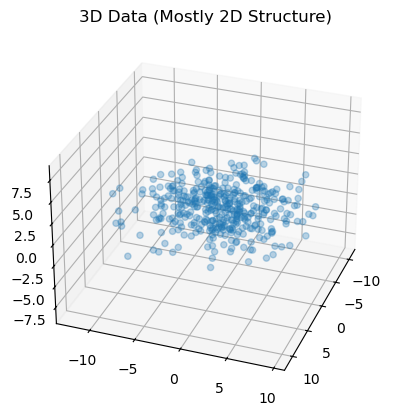

In [5]:
# just plot the data, and make axes equal so the structure shown is not distorted
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X[:,0], X[:,1], X[:,2], alpha=0.3)
ax.set_title("3D Data (Mostly 2D Structure)")
ax.view_init(elev=30, azim=20)
plt.axis('equal')
plt.show()

In [6]:
## perform PCA with optimized python implementation (better numerically)
pca = PCA(n_components=3)
# get PC axes and project data onto them
X_pca = pca.fit_transform(X)

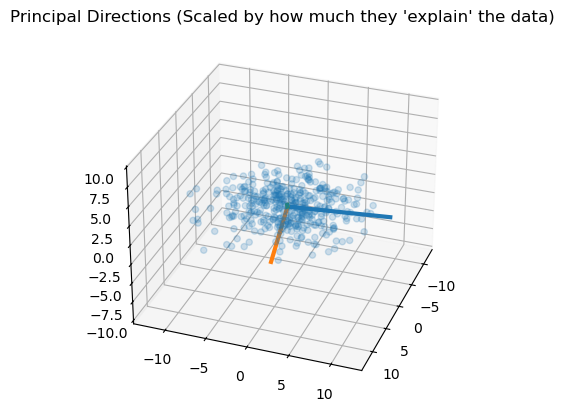

In [7]:
## visualize the principal directions in the original 3D space
mean = X.mean(axis=0)
components = pca.components_
variances = pca.explained_variance_

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X[:,0], X[:,1], X[:,2], alpha=0.2)

# draw scaled principal axes
for i in range(3):
    vec = components[i]
    scale = np.sqrt(variances[i]) * 3
    ax.plot(
        [mean[0], mean[0] + vec[0]*scale],
        [mean[1], mean[1] + vec[1]*scale],
        [mean[2], mean[2] + vec[2]*scale],
        linewidth=3
    )

ax.set_title("Principal Directions (Scaled by how much they 'explain' the data)")
ax.view_init(elev=30, azim=20)
plt.axis('equal')
plt.show()

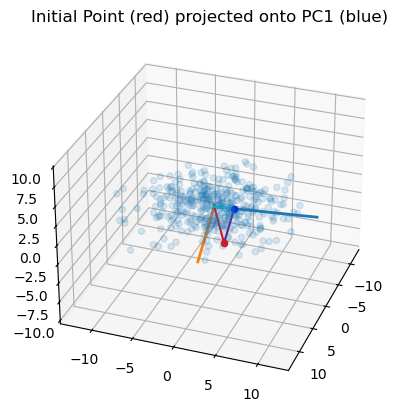

In [8]:
## projecting a datapoint on one dimension (here the blue one)
# pick one point
p = X[0]
p_centered = p - mean

pc1 = components[0]

# projection onto PC1
proj_length = p_centered @ pc1
proj_point = mean + proj_length * pc1

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# data
ax.scatter(X[:,0], X[:,1], X[:,2], alpha=0.15)

# principal axes (same as your code)
for i in range(3):
    vec = components[i]
    scale = np.sqrt(variances[i]) * 3
    ax.plot(
        [mean[0], mean[0] + vec[0]*scale],
        [mean[1], mean[1] + vec[1]*scale],
        [mean[2], mean[2] + vec[2]*scale],
        linewidth=2
    )

# original point
ax.scatter(p[0], p[1], p[2], color='red')

# projected point
ax.scatter(proj_point[0], proj_point[1], proj_point[2], color='blue')

# mean → point
ax.plot(
    [mean[0], p[0]],
    [mean[1], p[1]],
    [mean[2], p[2]], color='red'
)

# mean → projection (along PC1)
ax.plot(
    [mean[0], proj_point[0]],
    [mean[1], proj_point[1]],
    [mean[2], proj_point[2]], color='cyan'
)

# perpendicular drop
ax.plot(
    [p[0], proj_point[0]],
    [p[1], proj_point[1]],
    [p[2], proj_point[2]], color='purple'
)

ax.set_title("Initial Point (red) projected onto PC1 (blue)")
ax.view_init(elev=30, azim=20)
plt.axis('equal')
plt.show()

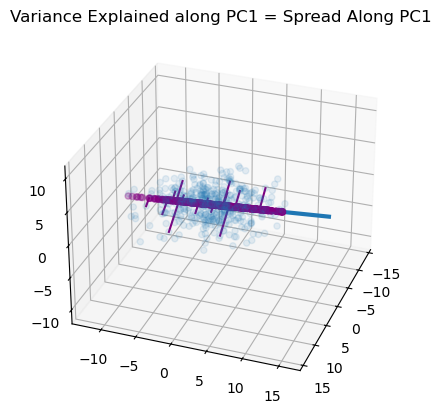

Explained variance ratio for PC1, PC2, PC3: [6.90588660e-01 3.08966417e-01 4.44922997e-04]


In [9]:
## intuition for variance explained by each PC
pc1 = components[0]

# project all points onto PC1
proj_lengths = (X - mean) @ pc1
proj_points = mean + np.outer(proj_lengths, pc1)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# original data
ax.scatter(X[:,0], X[:,1], X[:,2], alpha=0.1)

# PC1 axis
vec = pc1
scale = np.sqrt(variances[0]) * 4

ax.plot(
    [mean[0], mean[0] + vec[0]*scale],
    [mean[1], mean[1] + vec[1]*scale],
    [mean[2], mean[2] + vec[2]*scale],
    linewidth=3
)

# projected points (on axis)
ax.scatter(proj_points[:,0], proj_points[:,1], proj_points[:,2], color='purple')

# projection lines (subset for clarity)
for i in range(0, len(X), 25):
    ax.plot(
        [X[i,0], proj_points[i,0]],
        [X[i,1], proj_points[i,1]],
        [X[i,2], proj_points[i,2]], color='purple'
    )

ax.set_title("Variance Explained along PC1 = Spread Along PC1")
ax.view_init(elev=30, azim=20)
plt.axis('equal')
plt.show()
# show the explained variance ratio (how much variance - proportional to total variance - is captured by each PC)
print("Explained variance ratio for PC1, PC2, PC3:", pca.explained_variance_ratio_)

True


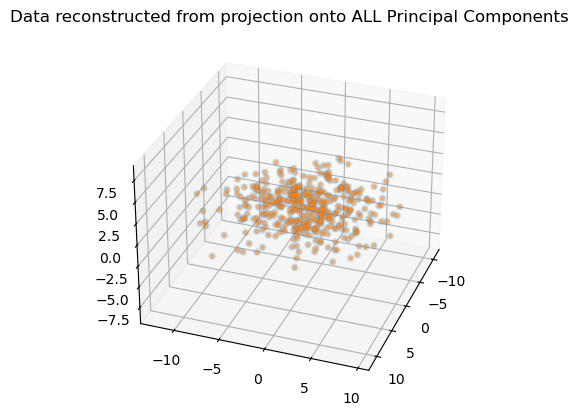

Manual point reconstruction: [ 4.35116947  2.56123539 -1.68976786]
Sklearn version: [ 4.35116947  2.56123539 -1.68976786]
Initial data: [ 4.35116947  2.56123539 -1.68976786]


In [ ]:
## control: using *ALL* PCs should give back the original data (up to numerical precision)
# PCA = project on new coordinates (PC axes; blue and orange axes above), then inverse_transform = project back (original axes in the graph above)
# What sklearn does internally:
# for data of dimension d (e.g. d neurons) and k principal components (e.g. k=2), with n datapoints (e.g. n trials by timepoints):
# Let:
# W = principal axes (shape: k × d) = pca2.components_
# Z = projected data (shape: n × k) = X_2d
# μ = mean vector
# Then:
# Projection:
# Z = (X - μ) Wᵀ
# Reconstruction:
# X̂ = Z W + μ
# This is just a change of basis + undoing it

pcaFull = PCA(n_components=3)
# this is the projection step into the PC axes
X_Full = pcaFull.fit_transform(X)
# project back to 3D space (reconstruction from all dimensions: "rebuilds" the data using all dimensions
X_proj = pcaFull.inverse_transform(X_Full)
# checking that this is just a projection:
W = pcaFull.components_          # shape (3, 3)
mu = X.mean(axis=0)

# manual reconstruction
X_manual = X_Full @ W + mu

# sklearn reconstruction
X_sklearn = pcaFull.inverse_transform(X_Full)

print(np.allclose(X_manual, X_sklearn))
# this prints 'true' if they are the same


fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# original
ax.scatter(X[:,0], X[:,1], X[:,2], alpha=0.15)

# projected (onto PCA plane)
ax.scatter(X_proj[:,0], X_proj[:,1], X_proj[:,2], alpha=0.4, s=6)


ax.set_title("Data reconstructed from projection onto ALL Principal Components")
ax.view_init(elev=30, azim=20)
plt.axis('equal')
plt.show()

# same but for a single point
# basis vectors in original space
pc1 = W[0]
pc2 = W[1]
pc3 = W[2]
# reconstruct a single point from coordinates
z = X_Full[0]
reconstructed = mu + z[0]*pc1 + z[1]*pc2 + z[2]*pc3
print("Manual point reconstruction:", reconstructed)
print("Sklearn version:", X_sklearn[0])
print("Initial data:", X[0])

True


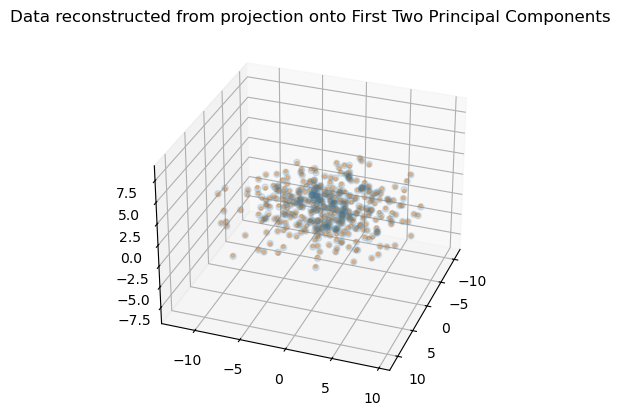

Manual point reconstruction: [ 4.33557665  2.56130328 -1.72869695]
Sklearn version: [ 4.33557665  2.56130328 -1.72869695]
Initial data: [ 4.35116947  2.56123539 -1.68976786]


In [ ]:
## Show what the data looks like if only acounting for the first 2 principal components (should be a great reconstruction since the data is mostly 2D)
# PCA = project on new coordinates (PC axes; blue and orange axes above), then inverse_transform = project back (original axes in the graph above)
# What sklearn does internally:
# for data of dimension d (e.g. d neurons) and k principal components (e.g. k=2), with n datapoints (e.g. n trials by timepoints):
# Let:
# W = principal axes (shape: k × d) = pca2.components_
# Z = projected data (shape: n × k) = X_2d
# μ = mean vector
# Then:
# Projection:
# Z = (X - μ) Wᵀ
# Reconstruction:
# X̂ = Z W + μ
# This is just a change of basis + undoing it

pca2 = PCA(n_components=2)
# this is the projection step into the PC axes
X_2d = pca2.fit_transform(X)
# project back to 3D space (reconstruction from 2D: "rebuilds" the data using only the most important dimensions)
X_proj = pca2.inverse_transform(X_2d)

# checking that this is just a projection:
W = pca2.components_          # shape (2, 3)
mu = X.mean(axis=0)

# manual reconstruction
X_manual = X_2d @ W + mu

# sklearn reconstruction
X_sklearn = pca2.inverse_transform(X_2d)

print(np.allclose(X_manual, X_sklearn))
# this prints 'true' if they are the same


fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# original
ax.scatter(X[:,0], X[:,1], X[:,2], alpha=0.15)

# projected (onto PCA plane)
ax.scatter(X_proj[:,0], X_proj[:,1], X_proj[:,2], alpha=0.4, s=6)

ax.set_title("Data reconstructed from projection onto First Two Principal Components")
ax.view_init(elev=30, azim=20)
plt.axis('equal')
plt.show()

# same but for a single point
# basis vectors in original space
pc1 = W[0]
pc2 = W[1]
# reconstruct a single point from coordinates
z = X_2d[0]
reconstructed = mu + z[0]*pc1 + z[1]*pc2
print("Manual point reconstruction:", reconstructed)
print("Sklearn version:", X_sklearn[0])
print("Initial data:", X[0])

True


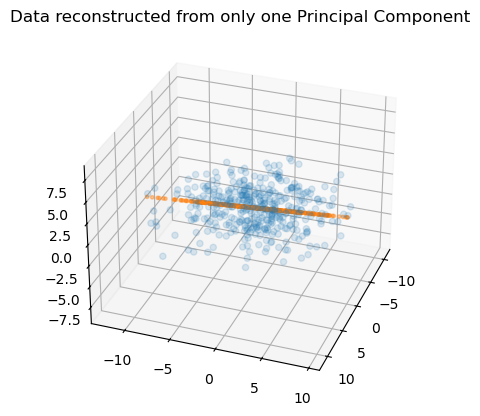

Manual point reconstruction: [-0.39267486  2.09147339  0.164357  ]
Sklearn version: [-0.39267486  2.09147339  0.164357  ]
Initial data: [ 4.35116947  2.56123539 -1.68976786]


In [ ]:
## Your turn: try this with only one principal component (k=1) and see how the reconstruction looks! (same code as the two cells above)

pca1 = PCA(n_components=1)
# this is the projection step into the PC axes
X_1d = pca1.fit_transform(X)
# project back to 3D space (reconstruction from 1D: "rebuilds" the data using only the first principal component)
X_proj = pca1.inverse_transform(X_1d)
# checking that this is just a projection:
W = pca1.components_          # shape (3, 3)
mu = X.mean(axis=0)

# manual reconstruction
X_manual = X_1d @ W + mu

# sklearn reconstruction
X_sklearn = pca1.inverse_transform(X_1d)

print(np.allclose(X_manual, X_sklearn))
# this prints 'true' if they are the same


fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# original
ax.scatter(X[:,0], X[:,1], X[:,2], alpha=0.15)

# projected (onto PCA plane)
ax.scatter(X_proj[:,0], X_proj[:,1], X_proj[:,2], alpha=0.4, s=6)


ax.set_title("Data reconstructed from only one Principal Component")
ax.view_init(elev=30, azim=20)
plt.axis('equal')
plt.show()

# same but for a single point
# basis vectors in original space
pc1 = W[0]
# reconstruct a single point from coordinates
z = X_1d[0]
reconstructed = mu + z[0]*pc1
print("Manual point reconstruction:", reconstructed)
print("Sklearn version:", X_sklearn[0])
print("Initial data:", X[0])

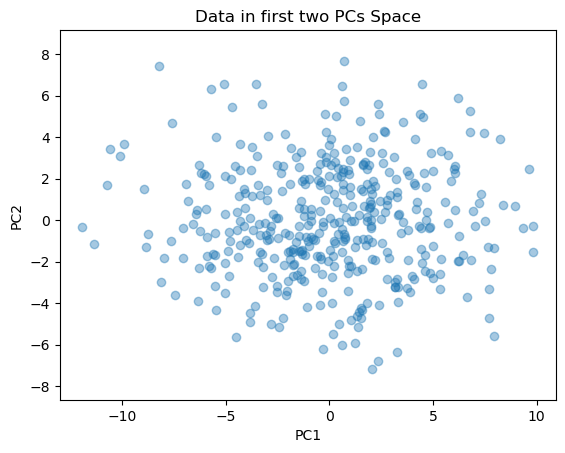

Explained variance ratio: PC1 captures about twice as much variance as PC2 (spread along PC1 is about twice as big as spread along PC2), and PC3 captures very little.
PC1: 0.691
PC2: 0.309
PC3: 0.000

Total percent variance explained bu first 2 PCs is almost 100% : 0.9995550770030897


In [ ]:
# we get back in PCA space: the data projected along the blue and orange axes in cell 17
plt.scatter(X_2d[:,0], X_2d[:,1], alpha=0.4)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Data in first two PCs Space")
plt.axis('equal')
plt.show()

print("Explained variance ratio: PC1 captures about twice as much variance as PC2 (spread along PC1 is about sqrt(2) as big as spread along PC2), and PC3 captures very little.")
for i, v in enumerate(pca.explained_variance_ratio_):
    print(f"PC{i+1}: {v:.3f}")

print("\nTotal percent variance explained bu first 2 PCs is almost 100% :", sum(pca.explained_variance_ratio_[:2]))


In [14]:
##### perform PCA with more manual implementation (for educational purposes)

## center the data
X_centered = X - X.mean(axis=0)

## compute covariance matrix
Sigma = np.cov(X_centered, rowvar=False)

## eigen-decomposition
eigvals, eigvecs = np.linalg.eigh(Sigma)
# sort in descending order
idx = np.argsort(eigvals)[::-1]
eigvals = eigvals[idx]
eigvecs = eigvecs[:, idx]
print("Eigenvalues:", eigvals)

## compare eigenvector directions with sklearn PCA
print("Sklearn components (rows):")
print(pca.components_)
print("Eigenvectors (columns):")
print(eigvecs.T)
# note that we expect the same direction, but there can be an arbitrary sign flip, so we check if they are approximately equal up to sign.
# the sign flip is because eigenvectors are only defined up to a sign, so if v is an eigenvector, then -v is also an eigenvector with the same eigenvalue. PCA implementations can choose either one, so we check if they are approximately equal up to a sign flip.

## Compare projection of data points on eigenvectors
X_proj_eig = X_centered @ eigvecs[:, :2]
# projection via sklearn
X_proj_sklearn = X_2d
# compare numerically
print("Projection of data points on eigenvectors is consistent with sklearn:", np.allclose(np.abs(X_proj_eig), np.abs(X_proj_sklearn)))

Eigenvalues: [1.64468863e+01 7.35826667e+00 1.05961745e-02]
Sklearn components (rows):
[[-0.08467237  0.99577083  0.03565172]
 [ 0.92443297  0.09185769 -0.37011599]
 [ 0.37182559 -0.00161903  0.92830119]]
Eigenvectors (columns):
[[ 0.08467237 -0.99577083 -0.03565172]
 [ 0.92443297  0.09185769 -0.37011599]
 [ 0.37182559 -0.00161903  0.92830119]]
Projection of data points on eigenvectors is consistent with sklearn: True
